验证torch的安装

In [13]:
import random
import torch
from d2l import torch as d2l

### 生成数据集

In [14]:
def synthetic_data(w, b, num_examples):
    """生成y = Xw + b"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

### 生成features和label
**features 每一行包含二维数据样本，label每一行包含一个标签**

In [15]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features', features[0], '\nlabel:', labels[0])

features tensor([-1.7036,  0.7012]) 
label: tensor([-1.5869])


**第二个特征和label的散点图**

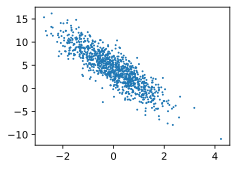

In [16]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

**第1个特征和label的散点图**

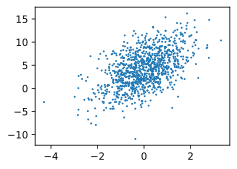

In [17]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (0)].detach().numpy(), labels.detach().numpy(), 1)

**读取数据集**

In [18]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这样样本是随机读取的，没有固定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        # 逐个生成值，而不是一次性生成所有值
        # 处理大数据时高效
        yield features[batch_indices], labels[batch_indices]

**初始化模型参数**

In [19]:
# w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
w = torch.zeros(size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

**定义模型**

In [20]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

**定义损失函数**

In [21]:
# def squard_loss(y_hat, y):
#     return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
def squard_loss(y_hat, y):
    return (y_hat - y) ** 2 / 2

**定义优化算法**

In [22]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 训练

In [23]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squard_loss
batch_size = 10
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward() #计算梯度并反向传播
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch:{epoch + 1}, loss:{float(train_l.mean()):f}')


epoch:1, loss:0.036486
epoch:2, loss:0.000132
epoch:3, loss:0.000052


In [24]:
print(f'w的估计误差:{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差:{true_b - b}')

w的估计误差:tensor([-4.4107e-05, -7.0071e-04], grad_fn=<SubBackward0>)
b的估计误差:tensor([-0.0002], grad_fn=<RsubBackward1>)
